In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("brfss_clean_2020_2024.csv")

race_map = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN",
    4: "Asian", 5: "NHOPI", 6: "Other/Multiracial",
    7: "Hispanic"
}
age_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
    5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
    9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}
sex_map = {1: "Male", 2: "Female"}
education_map = {
    1: "Did not graduate high school",
    2: "Graduated high school",
    3: "Attended college or technical school",
    4: "Graduated college or technical school"
}
income_map = {
    1: "<15k", 2: "15k-25k", 3: "25k-35k",
    4: "35k-50k", 5: "50k-100k", 6: "100k-200k", 7: "200k+"
}

df["race_group"]   = df["_RACEPRV"].map(race_map)
df["age_group"]    = df["_AGEG5YR"].map(age_map)
df["sex"]          = df["_SEX"].map(sex_map)
df["education"]    = df["_EDUCAG"].map(education_map)
df["income_group"] = df["_INCOMG1"].map(income_map)

# Reset index before splitting to avoid index alignment issues
df_model = df_model.reset_index(drop=True)

df_encoded = pd.get_dummies(df_model[["age_group", "sex", "education",
                                       "income_group", "race_group"]], drop_first=True)
state_dummies = pd.get_dummies(df_model["state_code"], prefix="state", drop_first=True)
X = pd.concat([df_encoded, state_dummies], axis=1)
y = df_model["obese"].values
w = df_model["_LLCPWT_adjusted"].values
race_all = df_model["race_group"].values

# Train test split
X_train, X_test, y_train, y_test, w_train, w_test, race_train, race_test = train_test_split(
    X, y, w, race_all, test_size=0.2, random_state=42, stratify=y
)

print("Fitting model...")
lr = LogisticRegression(max_iter=1000, solver="lbfgs")
lr.fit(X_train, y_train, sample_weight=w_train)
print("Done.")

print("\nTest set size:", len(X_test))
print("\nRace distribution in test set:")
race_counts = pd.Series(race_test).value_counts()
print(race_counts)

Fitting model...
Done.

Test set size: 264448

Race distribution in test set:
NH-White             199562
Hispanic              24390
NH-Black              20152
Other/Multiracial      7760
Asian                  7037
AIAN                   4243
NHOPI                  1304
Name: count, dtype: int64


In [3]:
# Overall AUC
y_pred = lr.predict_proba(X_test)[:, 1]
overall_auc = roc_auc_score(y_test, y_pred, sample_weight=w_test)
print(f"Overall weighted AUC: {overall_auc:.4f}")

# Race-specific AUC
print("\n=== RACE-SPECIFIC AUC ===")
race_results = []

for race in sorted(pd.Series(race_test).unique()):
    mask = race_test == race
    n = mask.sum()
    y_race = y_test[mask]
    pred_race = y_pred[mask]
    w_race = w_test[mask]
    
    # Check if both classes present
    if len(np.unique(y_race)) < 2:
        print(f"{race:20s} — n={n:6,} — AUC: N/A (only one class)")
        continue
    
    auc = roc_auc_score(y_race, pred_race, sample_weight=w_race)
    obesity_rate = np.average(y_race, weights=w_race)
    
    race_results.append({
        "race_group": race,
        "n": n,
        "obesity_rate": round(obesity_rate, 4),
        "auc": round(auc, 4)
    })
    
    flag = "⚠️ LOW" if auc < 0.60 else "✅"
    print(f"{race:25s} — n={n:6,} — obesity={obesity_rate:.3f} — AUC={auc:.4f} {flag}")

race_auc_df = pd.DataFrame(race_results).sort_values("auc")
print("\n=== SUMMARY ===")
print(race_auc_df.to_string(index=False))

Overall weighted AUC: 0.6354

=== RACE-SPECIFIC AUC ===
AIAN                      — n= 4,243 — obesity=0.372 — AUC=0.6100 ✅
Asian                     — n= 7,037 — obesity=0.128 — AUC=0.6013 ✅
Hispanic                  — n=24,390 — obesity=0.372 — AUC=0.5883 ⚠️ LOW
NH-Black                  — n=20,152 — obesity=0.445 — AUC=0.5963 ⚠️ LOW
NH-White                  — n=199,562 — obesity=0.333 — AUC=0.6204 ✅
NHOPI                     — n= 1,304 — obesity=0.408 — AUC=0.5448 ⚠️ LOW
Other/Multiracial         — n= 7,760 — obesity=0.327 — AUC=0.6150 ✅

=== SUMMARY ===
       race_group      n  obesity_rate    auc
            NHOPI   1304        0.4077 0.5448
         Hispanic  24390        0.3716 0.5883
         NH-Black  20152        0.4449 0.5963
            Asian   7037        0.1281 0.6013
             AIAN   4243        0.3725 0.6100
Other/Multiracial   7760        0.3273 0.6150
         NH-White 199562        0.3333 0.6204


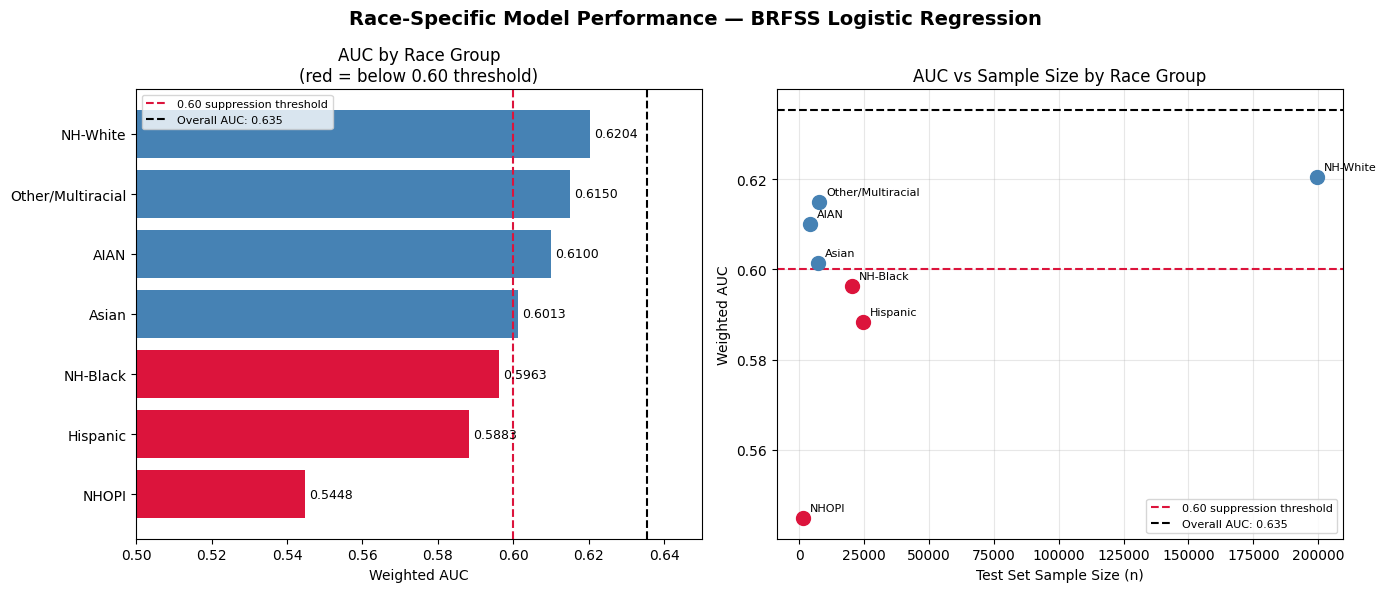

saved brfss_race_auc_plots.png
saved brfss_race_auc.csv


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Race-Specific Model Performance — BRFSS Logistic Regression",
             fontsize=14, fontweight="bold")

# Plot 1 — AUC by race
ax = axes[0]
colors = ["crimson" if a < 0.60 else "steelblue" for a in race_auc_df["auc"]]
bars = ax.barh(race_auc_df["race_group"], race_auc_df["auc"], color=colors)
ax.axvline(0.60, color="crimson", linestyle="--", linewidth=1.5,
           label="0.60 suppression threshold")
ax.axvline(overall_auc, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall AUC: {overall_auc:.3f}")
ax.set_xlabel("Weighted AUC")
ax.set_title("AUC by Race Group\n(red = below 0.60 threshold)")
ax.legend(fontsize=8)
ax.set_xlim(0.5, 0.65)
for bar, val in zip(bars, race_auc_df["auc"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va="center", fontsize=9)

# Plot 2 — AUC vs sample size
ax = axes[1]
for _, row in race_auc_df.iterrows():
    color = "crimson" if row["auc"] < 0.60 else "steelblue"
    ax.scatter(row["n"], row["auc"], color=color, s=100, zorder=5)
    ax.annotate(row["race_group"],
                (row["n"], row["auc"]),
                fontsize=8, xytext=(5, 5),
                textcoords="offset points")
ax.axhline(0.60, color="crimson", linestyle="--", linewidth=1.5,
           label="0.60 suppression threshold")
ax.axhline(overall_auc, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall AUC: {overall_auc:.3f}")
ax.set_xlabel("Test Set Sample Size (n)")
ax.set_ylabel("Weighted AUC")
ax.set_title("AUC vs Sample Size by Race Group")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("brfss_race_auc_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved brfss_race_auc_plots.png")

# Save results
race_auc_df.to_csv("brfss_race_auc.csv", index=False)
print("saved brfss_race_auc.csv")

## Race-Specific AUC Analysis

### Overview
Weighted AUC computed separately for each racial group on the 20% test set
(264,448 individuals). Overall weighted AUC is 0.635.

### Results

| Race Group | Test n | Obesity Rate | AUC | Flag |
|------------|--------|--------------|-----|------|
| NH-White | 199,562 | 33.3% | 0.6204 | ✅ |
| Other/Multiracial | 7,760 | 32.7% | 0.6150 | ✅ |
| AIAN | 4,243 | 37.2% | 0.6100 | ✅ |
| Asian | 7,037 | 12.8% | 0.6013 | ✅ |
| NH-Black | 20,152 | 44.5% | 0.5963 | ⚠️ LOW |
| Hispanic | 24,390 | 37.2% | 0.5883 | ⚠️ LOW |
| NHOPI | 1,304 | 40.8% | 0.5448 | ⚠️ LOW |

### Key Findings

**Three groups fall below the 0.60 suppression threshold.**
NHOPI (0.545), Hispanic (0.588), and NH-Black (0.596) have AUC below 0.60,
meaning demographic features explain relatively little of the within-group
obesity variation for these populations.

**NHOPI low AUC is driven by sample size.**
Only 1,304 NHOPI test observations — insufficient for the model to learn
reliable within-group demographic patterns. This is a data availability
problem, not a model failure.

**Hispanic and NH-Black low AUC is a structural issue.**
Despite having 24,390 and 20,152 test observations respectively, both groups
fall below 0.60. Demographics alone do not adequately explain obesity variation
within these communities. Cultural, geographic, and socioeconomic factors
not captured in BRFSS demographics likely drive within-group variation.

**NH-White dominates model performance.**
199,562 test observations and highest AUC (0.620). The overall AUC of 0.635
is largely driven by NH-White performance given its sample dominance.